#Introduccion y Objetivos

*Introduccion del analisis :*

La industria musical ha experimentado una transformación radical en las últimas décadas, impulsada principalmente por el auge de las plataformas de streaming. Spotify, con más de 600 millones de usuarios activos a nivel mundial, se ha consolidado como el principal referente del consumo musical global, generando en el proceso una cantidad masiva de datos que permiten estudiar con precisión los patrones de escucha, las preferencias del público y la evolución del éxito comercial en la música contemporánea.

El presente trabajo tiene como objetivo analizar el dataset Spotify, el cual reúne información sobre las 100 canciones más escuchadas de todos los tiempos en la plataforma. El dataset incluye variables de diversa naturaleza: identificadores de ranking, metadatos de las canciones, métricas de consumo, acústicas y musicales, y atributos del artista como su país de origen y su género musical principal, entre otras.

**Pregunta Principal :**     
¿ Que artistas son los mas escuchados ?

Subpreguntas :

¿ En que año se crearon las canciones mas escuchadas ?


¿ Existe alguna relación entre el género musical y variables como bpm en las canciones más escuchadas ?

Trabajo realizado por elias turquie

#Importación De Librerias

In [2]:
#Importo librería para manipulación y tratamiento de datos
import pandas as pd

#Importo librería para visualización y gráficos
import matplotlib.pyplot as plt

#Importo librería para visualización y gráficos
import seaborn as sns



# Carga y Exploración De Datos / Ingesta y Limpieza

Carga de dataset

In [3]:
#Le da instruccion de leer el csv, alojado en este caso mi drive
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset Trabajo final/spotify_alltime_top100_songs.csv')

##Exploración De Datos

In [4]:
#Lectura de datos , las primeras 4 filas
df.head(4)

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100


In [8]:
#Lectura de datos , las ultimas 4 filas
df.tail(4)

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
96,97,Blinding Lights (Remix),The Weeknd & Rosalía,1.44,Synth-Pop,171,2020,Canada/Spain,False,0.54,0.80,0.36,0.01,Spotify All-Time Most Streamed Top 100
97,98,Falling For You,Peachy feat. mxmtoon,1.56,Indie Pop,150,2018,USA,False,0.64,0.42,0.72,0.38,Spotify All-Time Most Streamed Top 100
98,99,Laugh Now Cry Later,Drake ft. Lil Durk,3.05,Hip-Hop,142,2020,Canada,True,0.82,0.62,0.55,0.02,Spotify All-Time Most Streamed Top 100
99,100,Shake It Off,Taylor Swift,1.60,Pop,160,2014,USA,False,0.65,0.80,0.94,0.06,Spotify All-Time Most Streamed Top 100


In [9]:
#Informacion sobre Filas y columnas
df.shape

(100, 14)

In [10]:
#Ver tipos de datos que tengo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   alltime_rank            100 non-null    int64  
 1   song_title              100 non-null    object 
 2   artist                  100 non-null    object 
 3   total_streams_billions  100 non-null    float64
 4   primary_genre           100 non-null    object 
 5   bpm                     100 non-null    int64  
 6   release_year            100 non-null    int64  
 7   artist_country          100 non-null    object 
 8   explicit                100 non-null    bool   
 9   danceability            100 non-null    float64
 10  energy                  100 non-null    float64
 11  valence                 100 non-null    float64
 12  acousticness            100 non-null    float64
 13  dataset_part            100 non-null    object 
dtypes: bool(1), float64(5), int64(3), object(5)

In [11]:
# Identifica valores ausentes
display(df.isna().sum()) # Identifica valores ausentes

# Contabiliza filas duplicadas
print(df.duplicated().sum())

,0
alltime_rank,0
song_title,0
artist,0
total_streams_billions,0
primary_genre,0
bpm,0
release_year,0
artist_country,0
explicit,0
danceability,0


0


#Graficos Analiticos

##1)Grafico de barras : Se observa que ed sheeran lidera el top , le siguen Harry Styles y The Weeknd

/tmp/ipykernel_7253/282476931.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_artists_streams.index, y=top_10_artists_streams.values, palette='viridis')


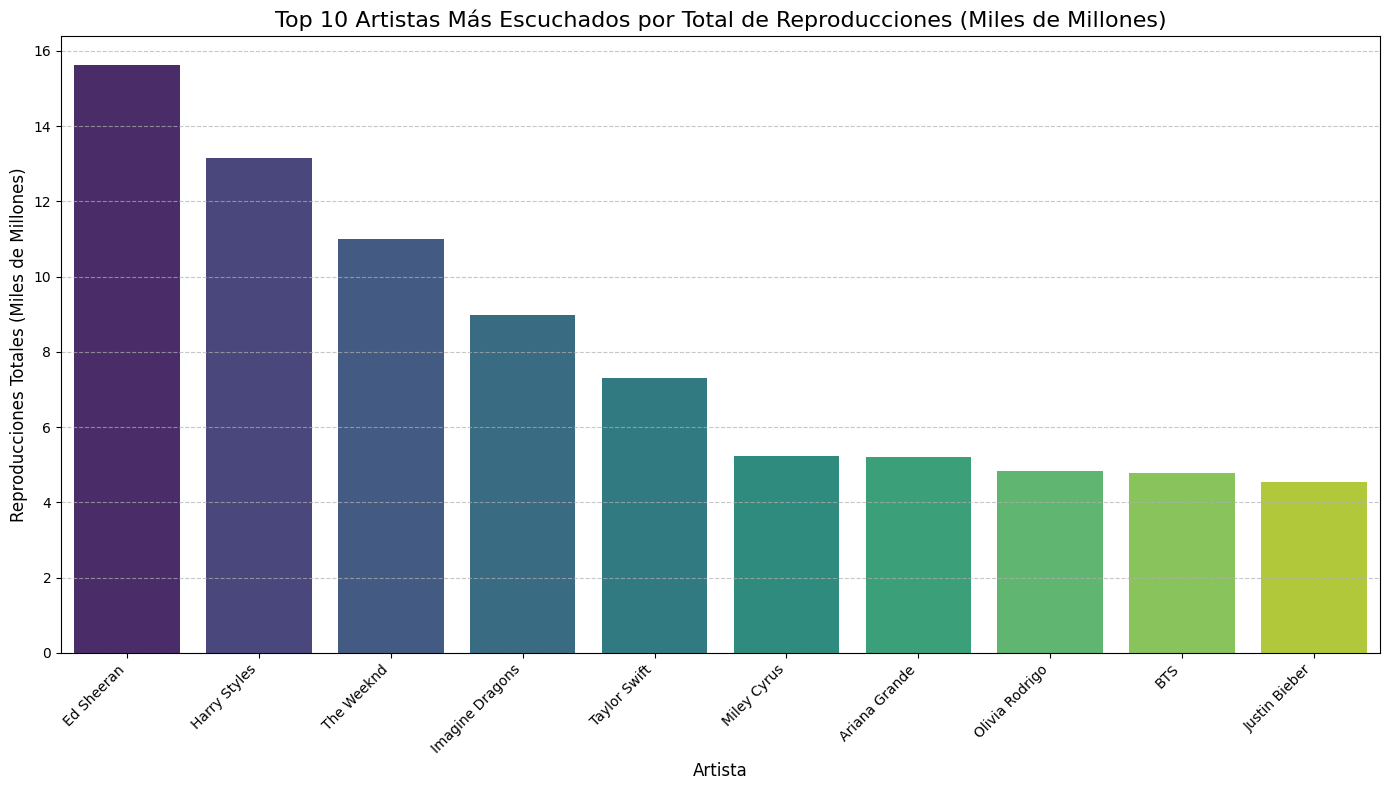

In [6]:
# Calcular las reproducciones totales por artista
artist_total_streams = df.groupby('artist')['total_streams_billions'].sum().sort_values(ascending=False)

# Seleccionar el top 10 de artistas
top_10_artists_streams = artist_total_streams.head(10)

# Crear el gráfico de barras
plt.figure(figsize=(14, 8))
sns.barplot(x=top_10_artists_streams.index, y=top_10_artists_streams.values, palette='viridis')
plt.title('Top 10 Artistas Más Escuchados por Total de Reproducciones (Miles de Millones)', fontsize=16)
plt.xlabel('Artista', fontsize=12)
plt.ylabel('Reproducciones Totales (Miles de Millones)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##2)Grafico Histograma : Se observa que el lanzamiento de canciones mas escuchadas fueron entre 2019 y 2020

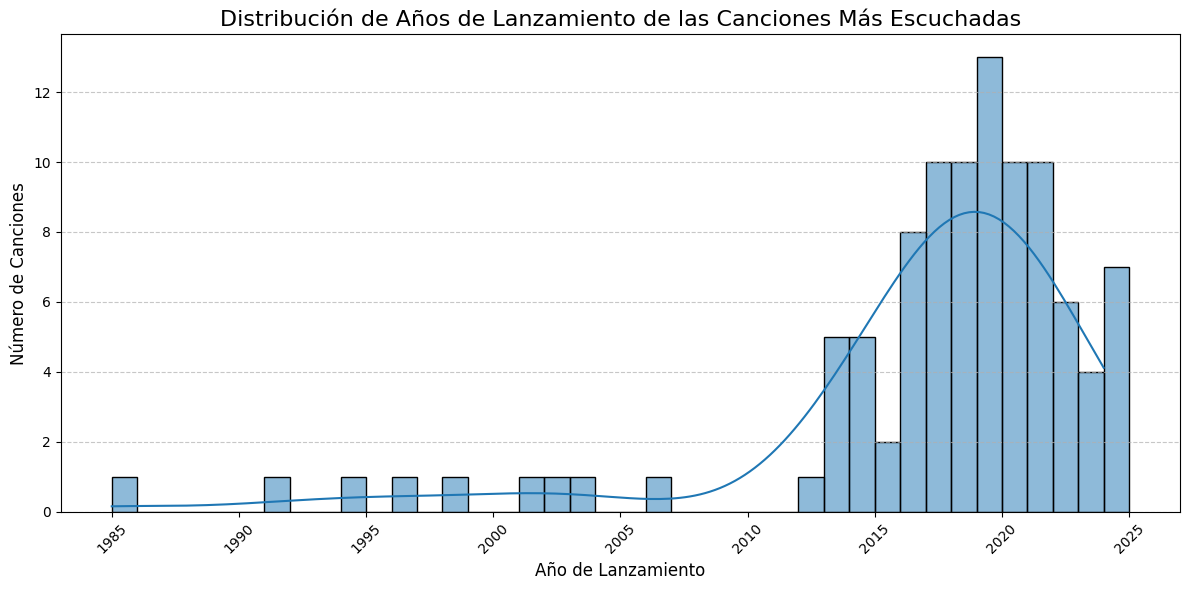

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(df['release_year'], bins=range(df['release_year'].min(), df['release_year'].max() + 2), kde=True)
plt.title('Distribución de Años de Lanzamiento de las Canciones Más Escuchadas', fontsize=16)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Número de Canciones', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##3)Grafico De Disperción : Se observa una concentración entre los 90 y 130 BPM.

/tmp/ipykernel_9691/2193132351.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='primary_genre', y='bpm', data=df, jitter=0.2, palette='tab10', size=6, alpha=0.8)


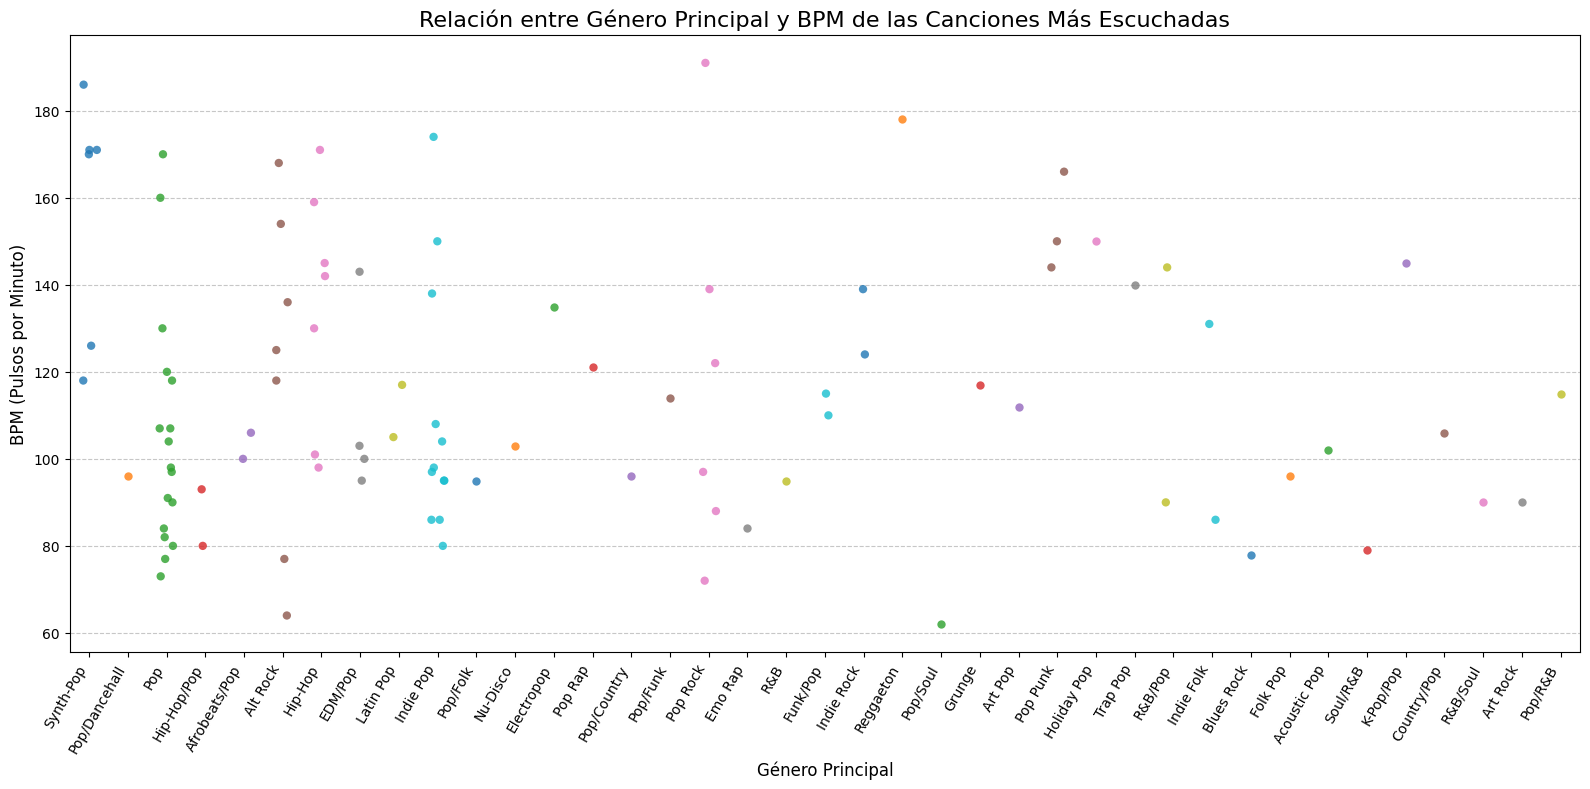

In [ ]:
plt.figure(figsize=(16, 8))
sns.stripplot(x='primary_genre', y='bpm', data=df, jitter=0.2, palette='tab10', size=6, alpha=0.8)
plt.title('Relación entre Género Principal y BPM de las Canciones Más Escuchadas', fontsize=16)
plt.xlabel('Género Principal', fontsize=12)
plt.ylabel('BPM (Pulsos por Minuto)', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()